# Pytorch kind of implementation

In [154]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline



In [155]:
g = torch.Generator().manual_seed(2147483647)

## Linear layer

In [156]:
class Linear:

    def __init__(self , fan_in , fan_out , bias=True):
        self.weight = torch.randn((fan_in , fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self , x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

## BatchNorm1D layer

In [157]:
class BatchNorm1d:
    def __init__(self , dim , eps=1e-5 , momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # parameters (trained with backprop)

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffer (trained with a running  momentum update)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)


    def __call__(self , x):
        # calculate the forward pass 

        if self.training:
            xmean = x.mean(0 , keepdim=True)
            xvar = x.var(0, keepdim=True )

        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        # update the buffers 
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)* self.running_mean  + self.momentum * xmean
                self.running_var = (1- self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma , self.beta] 

## Tanh layer

In [158]:
class Tanh:
    def __call__(self , x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

### Preparing data

In [159]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words)))) 
stoi = {
    s:i+1 for i,s in enumerate(chars)
}
stoi['.'] =0
itos = {
    i:s for s,i in stoi.items()
}

vocab_size = len(stoi)

### Building dataset

In [160]:
block_size = 3

def build_dataset(words):
    X,Y = [],[]

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

### Splitting the data 


In [161]:
import random
random.seed()

random.shuffle(words)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev , Ydev = build_dataset(words[n1:n2])
Xtest , Ytest = build_dataset(words[n2:])

torch.Size([182485, 3]) torch.Size([182485])
torch.Size([22940, 3]) torch.Size([22940])
torch.Size([22721, 3]) torch.Size([22721])


### Initilization of nn

In [162]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # number of neurons in the hidden layer of mlp
block_size = 3

C = torch.randn((vocab_size , n_embd),      generator=g)
layers = [
    Linear(n_embd * block_size , n_hidden) ,BatchNorm1d(n_hidden) ,  Tanh(),
    Linear (n_hidden , n_hidden), BatchNorm1d(n_hidden), Tanh(),

    Linear (n_hidden , n_hidden),BatchNorm1d(n_hidden ),Tanh(),
    Linear (n_hidden , n_hidden),BatchNorm1d(n_hidden ), Tanh(),
    Linear (n_hidden , n_hidden),BatchNorm1d(n_hidden ), Tanh(),
    Linear (n_hidden , vocab_size),BatchNorm1d(vocab_size),
]


with torch.no_grad():
    # last layer : make less confident
    layers[-1].gamma *= 0.1
    # layers[-1].weight *= 0.1
    # all the other layers : apply gain
    for layer in layers[:-1]:
        if isinstance(layer , Linear):
            layer.weight *=5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]


print(sum(p.nelement() for p in parameters)) # number of parameters in total 

for p in parameters:
    p.requires_grad = True

47551


### Training 

In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,) , generator=g)
    Xb = Xtr[ix]
    Yb = Ytr[ix]
    
    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x , Yb) # loss function
    

    # backward pass

    for layer in layers:
        layer.out.retain_grad()


    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
      ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])  

      0/ 200000: 3.2916
  10000/ 200000: 2.1366
  20000/ 200000: 2.0987
  30000/ 200000: 1.7511
  40000/ 200000: 2.2040
  50000/ 200000: 2.2574
  60000/ 200000: 2.0923
  70000/ 200000: 1.8532
  80000/ 200000: 2.3013
  90000/ 200000: 2.4269
 100000/ 200000: 2.0024
 110000/ 200000: 1.8462
 120000/ 200000: 1.9512
 130000/ 200000: 2.2031
 140000/ 200000: 2.3537
 150000/ 200000: 1.8649
 160000/ 200000: 2.6938
 170000/ 200000: 2.3443
 180000/ 200000: 2.1804
 190000/ 200000: 1.9411


### Visualize histograms

layer 2 (      Tanh): mean +0.01 , std 0.69, saturated: 13.78%
layer 5 (      Tanh): mean -0.00 , std 0.74, saturated: 16.41%
layer 8 (      Tanh): mean -0.01 , std 0.75, saturated: 16.22%
layer 11 (      Tanh): mean -0.03 , std 0.77, saturated: 16.50%
layer 14 (      Tanh): mean -0.01 , std 0.78, saturated: 18.91%


Text(0.5, 1.0, 'activation distribution ')

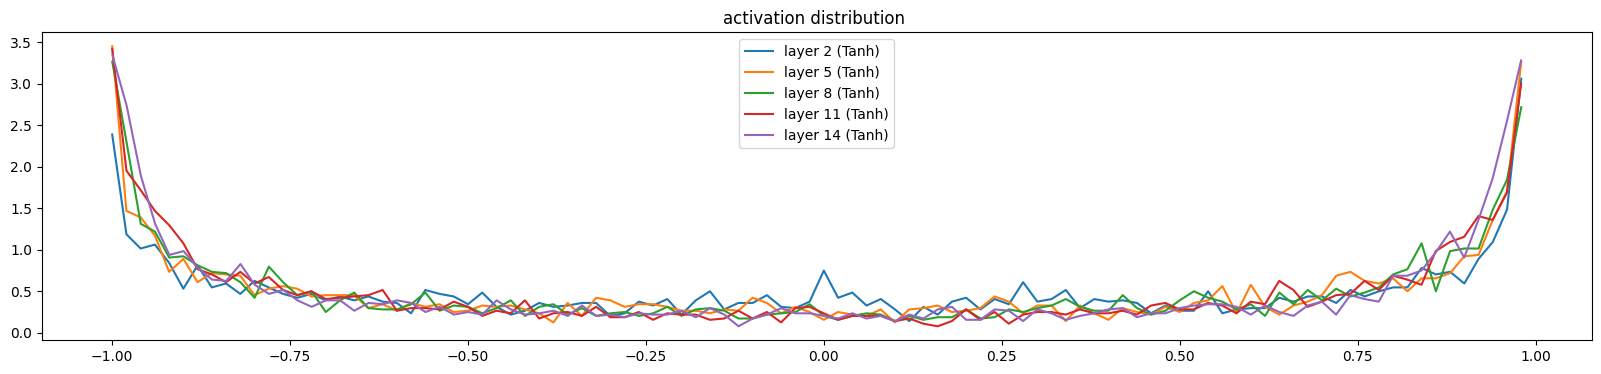

In [164]:
fig, ax = plt.subplots(figsize=(20,4))

legends = []

for i , layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f , std %.2f, saturated: %.2f%%' % (i , layer.__class__.__name__, t.mean(), t.std() , (t.abs() > 0.97).float().mean()*100))

        hy , hx = torch.histogram(t , density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title("activation distribution ")

layer 2 (      Tanh): mean -0.00 , std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean -0.00 , std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean -0.00 , std 0.00, saturated: 0.00%
layer 11 (      Tanh): mean -0.00 , std 0.00, saturated: 0.00%
layer 14 (      Tanh): mean +0.00 , std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution ')

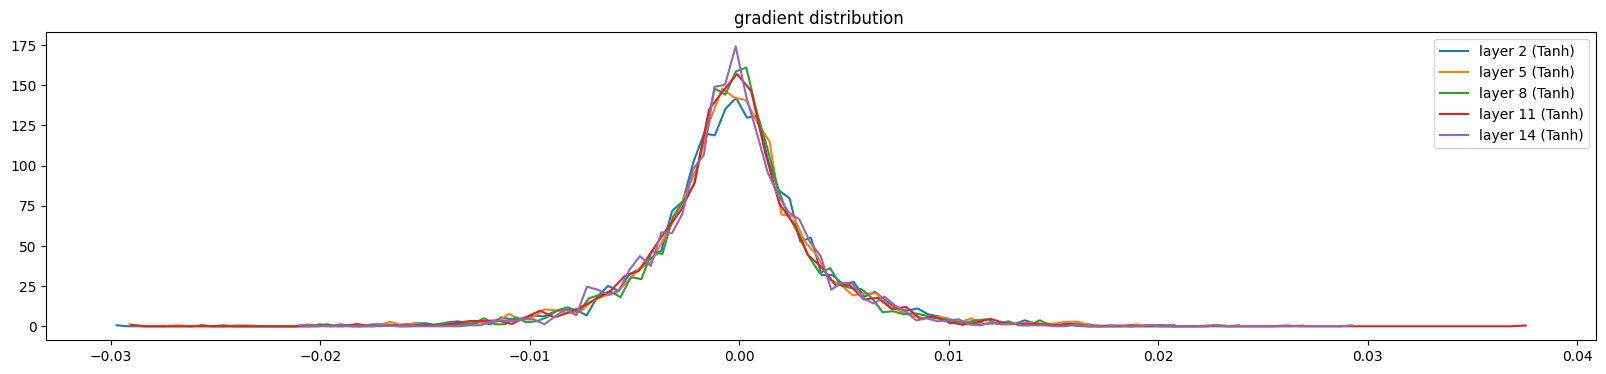

In [165]:
fig, ax = plt.subplots(figsize=(20,4))

legends = []

for i , layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f , std %.2f, saturated: %.2f%%' % (i , layer.__class__.__name__, t.mean(), t.std() , (t.abs() > 0.97).float().mean()*100))

        hy , hx = torch.histogram(t , density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')

plt.legend(legends)
plt.title("gradient distribution ")

weight   (27, 10) | mean +0.000000 | std 1.574528e-02 | grad:data ratio 1.443209e-02
weight  (30, 100) | mean +0.000180 | std 9.414620e-03 | grad:data ratio 2.292681e-02
weight (100, 100) | mean +0.000023 | std 5.834666e-03 | grad:data ratio 2.353813e-02
weight (100, 100) | mean +0.000032 | std 6.647174e-03 | grad:data ratio 2.736627e-02
weight (100, 100) | mean +0.000042 | std 5.722930e-03 | grad:data ratio 2.424585e-02
weight (100, 100) | mean -0.000039 | std 5.226385e-03 | grad:data ratio 2.292376e-02
weight  (100, 27) | mean -0.000008 | std 8.222939e-03 | grad:data ratio 2.500525e-02


Text(0.5, 1.0, 'weight and gradient distribution ')

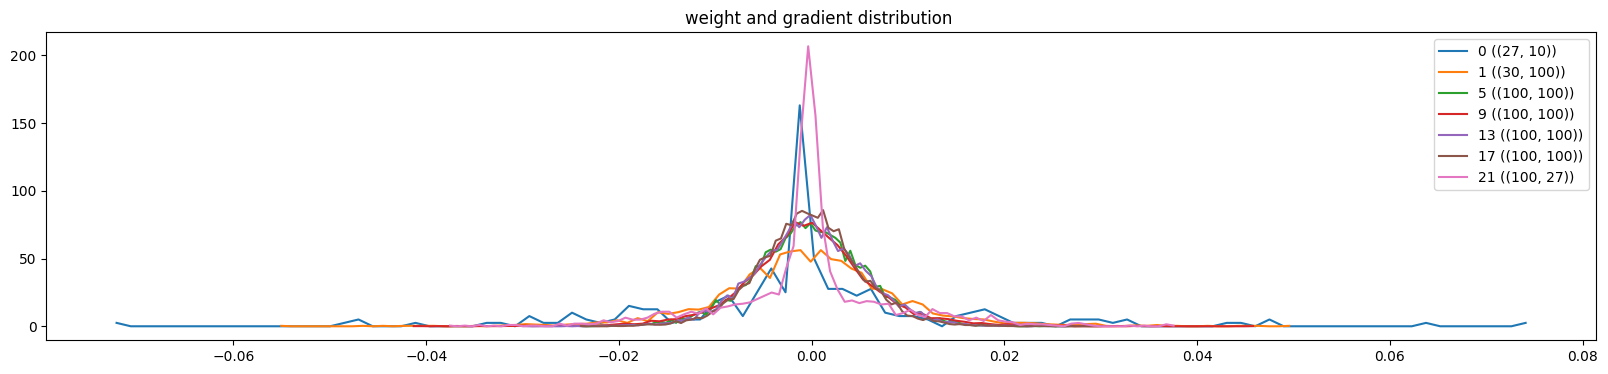

In [166]:
plt.figure(figsize=(20,4))

legends = []

for i , p in enumerate(parameters):
        t = p.grad
        if p.ndim == 2:
            print('weight %10s | mean %+f | std %e | grad:data ratio %e'% (tuple(p.shape)  , t.mean(), t.std() , t.std()/ p.std()))
            hy , hx = torch.histogram(t , density=True)
            plt.plot(hx[:-1].detach(), hy.detach())
            legends.append(f'{i} ({tuple(p.shape)})')
plt.legend(legends)
plt.title("weight and gradient distribution ")

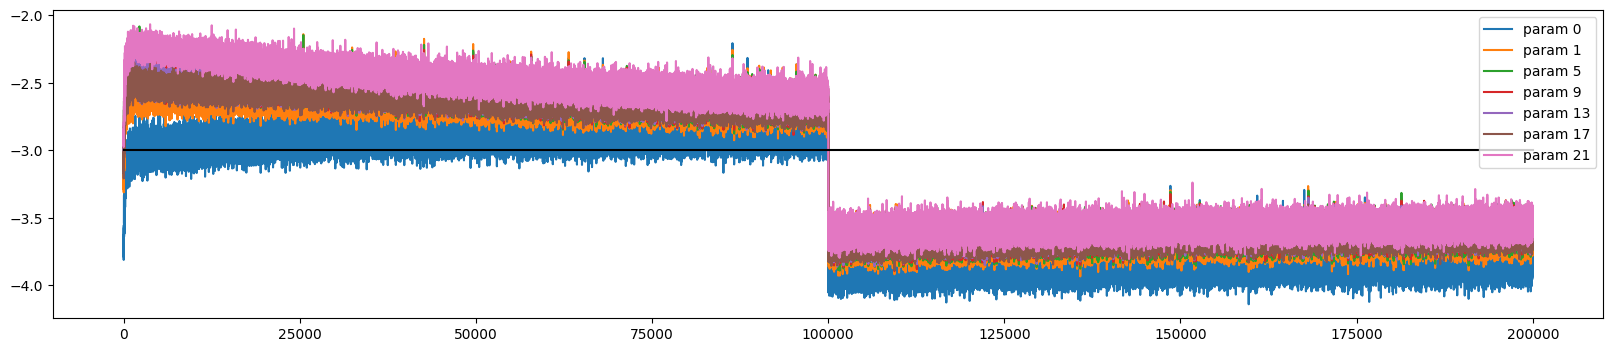

In [167]:
plt.figure(figsize=(20,4))
legends = []

for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0 , len(ud)] , [-3 , -3],'k')
plt.legend(legends)

In [1]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        "train": (Xtr, Ytr),
        "dev": (Xdev, Ydev),
        "test": (Xtest, Ytest)
    }[split]
    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(f"{split}: {loss.item():.4f}")

split_loss("train")
split_loss("dev")
split_loss("test")

NameError: name 'torch' is not defined

In [ ]:
# sample from the model

g = torch.Generator().manual_seed(2147483647 + 10)

for layer in layers:
    if hasattr(layer, 'training'):
        layer.training = False

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        # forward pass the neural net
        emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
        x = emb.view(1, -1)
        for layer in layers:
            x = layer(x)
        probs = F.softmax(x, dim=1)
        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special '.' token, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))